In [1]:
# All imports stays here

import os
import sys

import astropy.units as u
from astropy.convolution import convolve_fft
from astropy.io import fits
from astropy.wcs import WCS

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import numpy as np

from glob import glob

from reproject import reproject_interp

from scipy.fftpack import fft2, ifft2, fftshift
from scipy.signal import fftconvolve

from spectral_cube import SpectralCube

import stpsf

from tqdm.notebook import tqdm
from scipy.ndimage import shift as nd_shift
from photutils.psf.matching import create_matching_kernel, TukeyWindow, HanningWindow, resize_psf


**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-072
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf



Processing NGC253_ArIII_9.0.line.fits
  Line λ = 8.9900 µm  |  Band = 2B
Native PSF shift applied: (np.float64(-0.060097667508976826), np.float64(0.0007784361136415896))
Target PSF shift applied: (np.float64(-0.05588850056180661), np.float64(-0.0061780805395130756))
Kernel shift applied: (np.float64(0.024589458430206435), np.float64(0.0648627833787998))
Kernel subpixel offset (y, x): (np.float64(0.013312350447705512), np.float64(0.023771622310867713))
Kernel min: -0.004134969475945568
Kernel max: 0.08203920991508992
Kernel sum: 0.9990855099124025


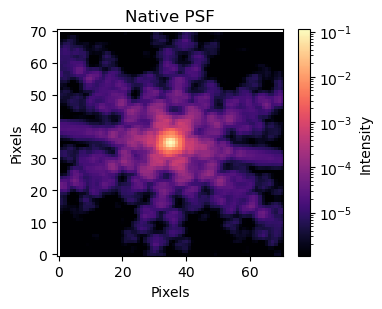

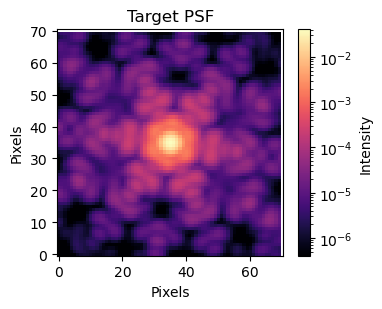

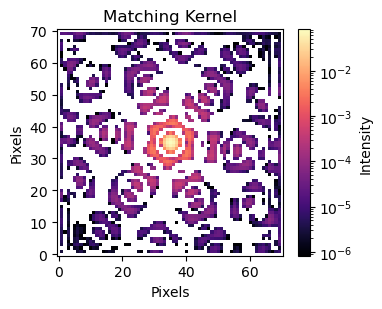

  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_ArIII_9.0.line_smooth.fits

Processing NGC253_ArII_7.0.line.fits
  Line λ = 6.9900 µm  |  Band = 1C


/Users/u826s018/miniconda3/envs/nearbygalaxies/lib/python3.11/site-packages/stpsf/opds.py:1759: UserWarning: For (V2,V3) = [-8.38815333 -5.31410167] arcmin, Field point -8.254199999999999 arcmin, -2.485898333333334 arcmin not within valid region for field dependence model of OTE WFE for MIRI: -8.254199999999999 arcmin--6.21738 arcmin, -2.557224 arcmin--0.5632056 arcmin.  Clipping to closest available valid location, 0.13395333333333426 arcmin away from the requested coordinates.
  warnings.warn(warning_message)


Native PSF shift applied: (np.float64(0.42066266756943094), np.float64(0.5009216475133229))
Target PSF shift applied: (np.float64(0.4269568962456134), np.float64(0.4912196507942852))
Kernel shift applied: (np.float64(-0.0139626836331459), np.float64(-0.018619262001429604))
Kernel subpixel offset (y, x): (np.float64(0.0024126527425920585), np.float64(0.0162760129177002))
Kernel min: -0.0016102482983759612
Kernel max: 0.04254349456711173
Kernel sum: 1.0004905932245582
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_ArII_7.0.line_smooth.fits

Processing NGC253_C2H2_13.7.line.fits
  Line λ = 13.7000 µm  |  Band = 3B


/Users/u826s018/miniconda3/envs/nearbygalaxies/lib/python3.11/site-packages/stpsf/opds.py:1759: UserWarning: For (V2,V3) = [-8.40143167 -5.31995333] arcmin, Field point -8.254199999999999 arcmin, -2.4800466666666674 arcmin not within valid region for field dependence model of OTE WFE for MIRI: -8.254199999999999 arcmin--6.21738 arcmin, -2.557224 arcmin--0.5632056 arcmin.  Clipping to closest available valid location, 0.14723166666666643 arcmin away from the requested coordinates.
  warnings.warn(warning_message)


Native PSF shift applied: (np.float64(0.45068370156532467), np.float64(0.5006154219997185))
Target PSF shift applied: (np.float64(0.45251372004273094), np.float64(0.49444661380557875))
Kernel shift applied: (np.float64(-0.008359134224456), np.float64(-0.012433337689891744))
Kernel subpixel offset (y, x): (np.float64(0.0047502391136760025), np.float64(0.007491106294093441))
Kernel min: -0.01603954883790425
Kernel max: 0.1663135072418934
Kernel sum: 1.0005710590424295
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_C2H2_13.7.line_smooth.fits

Processing NGC253_CO2_15.0.line.fits
  Line λ = 15.0000 µm  |  Band = 3B
Native PSF shift applied: (np.float64(0.4505878651496822), np.float64(0.4987550463828825))
Target PSF shift applied: (np.float64(0.45251372004273094), np.float64(0.49444661380557875))
Kernel shift applied: (np.float64(-0.005144874101269181), np.float64(-0.010818513193370904))
Kernel subpixel offset (y, x): (np.float64(0.004501695935537

...

Native PSF shift applied: (np.float64(0.4185711504561027), np.float64(0.5027371752694023))
Target PSF shift applied: (np.float64(0.4269568962456134), np.float64(0.4912196507942852))
Kernel shift applied: (np.float64(-0.014231360595672982), np.float64(-0.01929359483244042))
Kernel subpixel offset (y, x): (np.float64(7.216557403921797e-05), np.float64(0.01192703206787371))
Kernel min: -0.001222597205721254
Kernel max: 0.03990497612188289
Kernel sum: 1.000348687633046
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_H6g_5.9.line_smooth.fits

Processing NGC253_H7b_11.3.line.fits
  Line λ = 11.3100 µm  |  Band = 2C


/Users/u826s018/miniconda3/envs/nearbygalaxies/lib/python3.11/site-packages/stpsf/opds.py:1759: UserWarning: For (V2,V3) = [-8.38974833 -5.32495833] arcmin, Field point -8.254199999999999 arcmin, -2.4750416666666677 arcmin not within valid region for field dependence model of OTE WFE for MIRI: -8.254199999999999 arcmin--6.21738 arcmin, -2.557224 arcmin--0.5632056 arcmin.  Clipping to closest available valid location, 0.13554833333333427 arcmin away from the requested coordinates.
  warnings.warn(warning_message)


Native PSF shift applied: (np.float64(-0.058508010993485016), np.float64(-0.0014044417473968451))
Target PSF shift applied: (np.float64(-0.05588850056180661), np.float64(-0.0061780805395130756))
Kernel shift applied: (np.float64(0.021160214921252418), np.float64(0.04246350187737846))
Kernel subpixel offset (y, x): (np.float64(0.004665035620853075), np.float64(0.008428172990612381))
Kernel min: -0.0059864518769098774
Kernel max: 0.09480766720732932
Kernel sum: 0.999685166199781
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_H7b_11.3.line_smooth.fits

Processing NGC253_H7d_7.5.line.fits
  Line λ = 7.5100 µm  |  Band = 1C
Native PSF shift applied: (np.float64(0.420809975797809), np.float64(0.5022179520519643))
Target PSF shift applied: (np.float64(0.4269568962456134), np.float64(0.4912196507942852))
Kernel shift applied: (np.float64(-0.014346163985734961), np.float64(-0.018289078929214497))
Kernel subpixel offset (y, x): (np.float64(0.0035572264

/Users/u826s018/miniconda3/envs/nearbygalaxies/lib/python3.11/site-packages/stpsf/opds.py:1759: UserWarning: For (V2,V3) = [-8.39108833 -5.32144667] arcmin, Field point -8.254199999999999 arcmin, -2.478553333333333 arcmin not within valid region for field dependence model of OTE WFE for MIRI: -8.254199999999999 arcmin--6.21738 arcmin, -2.557224 arcmin--0.5632056 arcmin.  Clipping to closest available valid location, 0.13688833333333505 arcmin away from the requested coordinates.
  warnings.warn(warning_message)


Native PSF shift applied: (np.float64(-0.060698545230224), np.float64(0.0014827558610122082))
Target PSF shift applied: (np.float64(-0.05588850056180661), np.float64(-0.0061780805395130756))
Kernel shift applied: (np.float64(0.024393525051351617), np.float64(0.06652432370599115))
Kernel subpixel offset (y, x): (np.float64(0.013434942412466455), np.float64(0.02694431321025803))
Kernel min: -0.003960495132069474
Kernel max: 0.08086620823646705
Kernel sum: 0.9989942713187393
  → Saved ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth/NGC253_H7g_8.8.line_smooth.fits

Processing NGC253_H7i_5.5.line.fits
  Line λ = 5.5300 µm  |  Band = 1A
Native PSF shift applied: (np.float64(0.4195730111979472), np.float64(0.5042319910077424))
Target PSF shift applied: (np.float64(0.4269568962456134), np.float64(0.4912196507942852))
Kernel shift applied: (np.float64(-0.013731908501377177), np.float64(-0.0192503313280028))
Kernel subpixel offset (y, x): (np.float64(2.485916352412687e-

In [3]:
# --------------------------------------------------
# Band selection
# --------------------------------------------------
def band_from_wavelength(lam):
    lam = float(lam)
    if 4.90 <= lam <= 5.74:   return "1A"
    if 5.66 <= lam <= 6.63:   return "1B"
    if 6.53 <= lam <= 7.65:   return "1C"
    if 7.51 <= lam <= 8.77:   return "2A"
    if 8.67 <= lam <= 10.13:  return "2B"
    if 10.01 <= lam <= 11.70: return "2C"
    if 11.55 <= lam <= 13.47: return "3A"
    if 13.34 <= lam <= 15.57: return "3B"
    if 15.41 <= lam <= 17.98: return "3C"
    raise ValueError(f"Wavelength {lam} µm outside MIRI MRS range")


# --------------------------------------------------
# Kernel construction (Wiener deconvolution)
# --------------------------------------------------
def compute_matching_kernel(psf_native, psf_target, reg=1e-3):
    """
    Compute kernel K such that psf_native * K ≈ psf_target.
    Both input PSFs must have the same shape.
    """
    Fn = fft2(psf_native)
    Ft = fft2(psf_target)
    denom = np.abs(Fn)**2 + reg
    K = np.real(ifft2(np.conj(Fn) * Ft / denom))
    K = np.fft.fftshift(K)      
    K /= K.sum()          # flux conservation
    return K

# --------------------------------------------------
# Rest‑frame wavelengths for each line (from file names)
# --------------------------------------------------

rest_um = {
    "S9_5_0":    4.95,
    "S8_5_1":    5.05,
    "H6d_5_1":   5.13,
    "FeII_5_3":  5.34,
    "H7k_5_4":   5.38,
    "S7_5_5":    5.51,
    "H7i_5_5":   5.53,
    "MgV_5_6":   5.60,
    "H7t_5_7":   5.71,
    "S7_1-1_5_8":5.81,
    "H6g_5_9":   5.91,
    "H7e_6_0":   5.96,
    "S6_6_1":    6.11,
    "H7z_6_3":   6.29,
    "NiII_6_6":  6.64,
    "He_6_7":    6.72,
    "H7e_6_8":   6.77,
    "S5_6_9":    6.91,
    "ArII_7_0":  6.99,
    "NiIII_7_3": 7.35,
    "H5a_7_5":   7.46,
    "H5b_7_5":   7.50,
    "H7d_7_5":   7.51,
    "NeVI_7_7":  7.65,
    "H8t_7_8":   7.78,
    "S4_8_0":    8.03,
    "H7g_8_8":   8.76,
    "ArIII_9_0": 8.99,
    "S3_9_7":    9.66,
    "SIV_10_5":  10.51,
    "NiII_10_7": 10.68,
    "H7b_11_3":  11.31,
    "S2_12_3":   12.28,
    "H6a_12_4":  12.37,
    "H8g_12_4":  12.39,
    "NeII_12_8": 12.81,
    "MgV_13_5": 13.54,
    "C2H2_13_7": 13.70,
    "HCN_14_0": 14.0,
    "NeV_14_3":  14.32,
    "ClII_14_4": 14.37,
    "CO2_15_0": 15.0,
    "NeIII_15_6":15.56,
    "H8b_16_2":  16.21,
    "S1_17_0":   17.03,
    "PIII_17_9": 17.88,
}

def get_line_wavelength_from_dict(filename, rest_um):
    base = os.path.basename(filename)
    if base.startswith("NGC253_"):
        base = base.replace("NGC253_", "")
    base = base.replace(".line.fits", "")
    name_key = base.replace(".", "_")
    if name_key in rest_um:
        return rest_um[name_key]
    raise RuntimeError(f"Line '{name_key}' not found in rest_um dictionary (file: {filename})")

# --------------------------------------------------
# File directories
# --------------------------------------------------
IN_DIR   = "../../github/astr796_25_V2/NGC253_output/3channel/casa/atomic"
OUT_DIR  = "../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth"
TARGET_LAMBDA = 17.8846      # µm
TARGET_BAND   = "3C"
FILE_GLOB = os.path.join(IN_DIR, "*.line.fits")

os.makedirs(OUT_DIR, exist_ok=True)
files = sorted(glob(FILE_GLOB))

# --------------------------------------------------
# Main processing loop
# --------------------------------------------------
skipped_lines = []

for infile in files:
    name = os.path.basename(infile)
    print(f"\nProcessing {name}")

    with fits.open(infile) as hdul:
        flux = hdul[0].data
        hdr  = hdul[0].header
        # --- Pixel scale for THIS file (arcsec) ---
        pixscale = abs(hdr["CDELT2"]) * 3600.0

    # --- Determine line wavelength and band ---
    try:
        lam_line = get_line_wavelength_from_dict(infile, rest_um)
        band_line = band_from_wavelength(lam_line)
    except RuntimeError as e:
        print(f"Skipping {name}: {e}")
        skipped_lines.append(name)
        continue

    print(f"  Line λ = {lam_line:.4f} µm  |  Band = {band_line}")

    # --- Target PSF (computed for this file's pixel scale) ---
    miri_target = stpsf.MIRI()
    miri_target.mode = "IFU"
    miri_target.band = TARGET_BAND
    miri_target.pixelscale =pixscale     #setting the target area equal to native
    psf_target = miri_target.calc_psf(
        monochromatic=TARGET_LAMBDA * 1e-6
    )[3].data
    psf_target /= psf_target.sum()

    # --- Native PSF (at line wavelength, same pixel scale) ---
    miri_native = stpsf.MIRI()
    miri_native.mode = "IFU"
    miri_native.band = band_line
    miri_native.pixelscale = pixscale
    psf_native = miri_native.calc_psf(
        monochromatic=lam_line * 1e-6
    )[3].data
    psf_native /= psf_native.sum()

    # --- Pad both PSFs to same size (for FFT) ---
    h = max(psf_native.shape[0], psf_target.shape[0])
    w = max(psf_native.shape[1], psf_target.shape[1])
    
    # Make dimensions odd to remove FFT center ambiguity
    # This solves the shifting issues 
    if h % 2 == 0:
        h += 1
    if w % 2 == 0:
        w += 1

    def pad(psf):
        out = np.zeros((h, w))
        y = (h - psf.shape[0]) // 2
        x = (w - psf.shape[1]) // 2
        out[y:y+psf.shape[0], x:x+psf.shape[1]] = psf
        return out

    psf_native = pad(psf_native)
    psf_target = pad(psf_target)


    
    def recenter_psf(psf, method="fft_peak"):
   
        cy = (psf.shape[0] - 1) / 2.0
        cx = (psf.shape[1] - 1) / 2.0

        if method == "max_peak":
            peak_y, peak_x = np.unravel_index(np.nanargmax(psf), psf.shape)
            dy = cy - peak_y
            dx = cx - peak_x

        elif method == "centroid":
        # subpixel centroid using weighted average
            y, x = np.indices(psf.shape)
            total = psf.sum()
            peak_y = (y * psf).sum() / total
            peak_x = (x * psf).sum() / total
            dy = cy - peak_y
            dx = cx - peak_x

        else:
            raise ValueError("method must be 'max_peak' or 'centroid'")

        # Apply subpixel shift
        psf_rec = nd_shift(psf, shift=(dy, dx), order=3, mode='constant', cval=0.0)

        return psf_rec, (dy, dx)

    psf_native, shift_native = recenter_psf(psf_native, method="centroid")
    psf_target, shift_target = recenter_psf(psf_target, method="centroid")

    print("Native PSF shift applied:", shift_native)
    print("Target PSF shift applied:", shift_target)



    # --- A diagnostic plot ---
    def plot_psf(psf, title="PSF"):
        plt.figure(figsize=(4,3.2))
        plt.imshow(psf, origin='lower', cmap='magma',
               norm=LogNorm(vmin=psf.max()*1e-5, vmax=psf.max()))
        plt.colorbar(label='Intensity')
        plt.title(title)
        plt.xlabel('Pixels')
        plt.ylabel('Pixels')
        plt.tight_layout()
        plt.show()

    # --- Compute matching kernel ---
    kernel = compute_matching_kernel(psf_native, psf_target, reg=1e-3)

    # recentre kernel to same nominal center
    kernel, shift_kernel = recenter_psf(kernel, method="centroid")
    print("Kernel shift applied:", shift_kernel)

    # --------------------------------------------------
    # Diagnostic: kernel center check
    # --------------------------------------------------
    y, x = np.indices(kernel.shape)
    total = kernel.sum()

    cy_float = (y * kernel).sum() / total
    cx_float = (x * kernel).sum() / total

    cy_nom = (kernel.shape[0] - 1) / 2.0
    cx_nom = (kernel.shape[1] - 1) / 2.0

    offset_y = cy_float - cy_nom
    offset_x = cx_float - cx_nom
    print("Kernel subpixel offset (y, x):", (offset_y, offset_x))

    print("Kernel min:", kernel.min())
    print("Kernel max:", kernel.max())
    print("Kernel sum:", kernel.sum())

    #kernel = np.roll(kernel, shift=(-1,-1), axis=(0,1))
 
# ---- Plot for first file only (optional safety) ----
    if infile == files[0]:
        plot_psf(psf_native, "Native PSF")
        plot_psf(psf_target, "Target PSF")
        plot_psf(kernel, "Matching Kernel")

    # --- Convolve each slice (2D image) ---
    sm_flux = np.zeros_like(flux)
    for i in range(flux.shape[0]):
        img = np.nan_to_num(flux[i], nan=0.0)
        mask = ~np.isnan(flux[i])
        sm = fftconvolve(img, kernel, mode="same")
        sm[~mask] = np.nan
        sm_flux[i] = sm

    # --- Write output (flux only, no error extension) ---
    outname = os.path.join(OUT_DIR, name.replace(".fits", "_smooth.fits"))
    fits.writeto(outname, sm_flux, hdr, overwrite=True)
    print(f"  → Saved {outname}")

# --------------------------------------------------
# Summary of skipped files
# --------------------------------------------------
if skipped_lines:
    print("\n⚠ The following line files were skipped (not in rest_um dictionary):")
    for f in skipped_lines:
        print("   ", f)

print("\nAll available line maps PSF-homogenized correctly.")


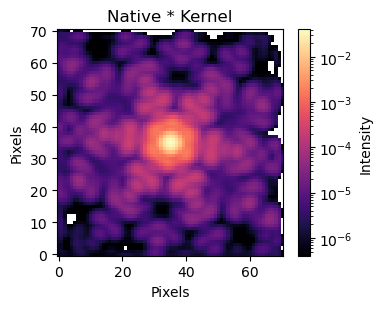

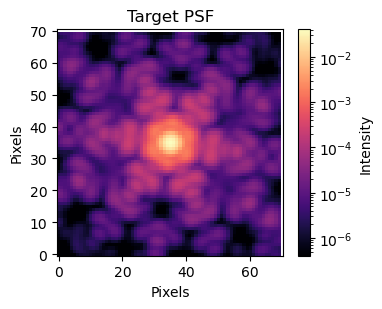

Recon RMS residual = 3.650e-05, peak diff frac = 5.160e-03


In [5]:
# random checks and diagnostic blocks

test = fftconvolve(psf_native, kernel, mode="same")
plot_psf(test, "Native * Kernel")
plot_psf(psf_target, "Target PSF")
psf_native.shape == psf_target.shape

recon = fftconvolve(psf_native, kernel, mode='same')

resid = psf_target - recon
rms = np.sqrt(np.nanmean(resid**2))
peak_diff = (psf_target.max() - recon.max()) / psf_target.max()

print(f"Recon RMS residual = {rms:.3e}, peak diff frac = {peak_diff:.3e}")


In [6]:
# This is regrdding
# One thing that I have done here
# Is passed the flux header to the data


# --- paths ---
smooth_dir = "../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth"
out_dir = "../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_regrid"
os.makedirs(out_dir, exist_ok=True)

# Reference cube (Fe II or ch4)
ref_path = os.path.join(smooth_dir, "NGC253_PIII_17.9.line_smooth.fits")
with fits.open(ref_path) as ref_hdul:
    ref_hdr = ref_hdul[0].header.copy()
    ref_data = ref_hdul[0].data.copy()
ref_wcs_3d = WCS(ref_hdr)
ref_wcs_2d = ref_wcs_3d.dropaxis(2)
ref_hdr_2d = ref_wcs_2d.to_header()
ny_ref, nx_ref = ref_data.shape[1], ref_data.shape[2]
shape_out_ref = (ny_ref, nx_ref)

# --- Input cubes ---
cube_files = sorted(glob(os.path.join(smooth_dir, "*.fits")))
print(f"Found {len(cube_files)} smoothed cubes.")

for infile in cube_files:
    name = os.path.basename(infile)
    outfile = os.path.join(out_dir, name.replace(".fits", "_regrid.fits"))

    # --- Read input cube ---
    data_in = fits.getdata(infile)
    hdr_in = fits.getheader(infile)
    wcs_in_3d = WCS(hdr_in)
    wcs_in_2d = wcs_in_3d.dropaxis(2)
    hdr_in_2d = wcs_in_2d.to_header()

    nlam = data_in.shape[0]
    print(f"Regridding {name}: {nlam} slices -> {shape_out_ref}")

    # --- Reproject slice by slice ---
    regridded = np.empty((nlam, ny_ref, nx_ref), dtype=np.float32)
    for i in range(nlam):
        plane = data_in[i].astype(float)
        plane_masked = np.where(np.isfinite(plane), plane, np.nan)
        out_plane, _ = reproject_interp((plane_masked, hdr_in_2d),
                                        ref_hdr_2d, shape_out=shape_out_ref)
        regridded[i] = out_plane

    # --- Build output header ---
    out_hdr = ref_hdr.copy()
    out_hdr["NAXIS3"] = nlam
    for key in hdr_in:
        if "3" in key or key.startswith("REST") or key.startswith("SPECSYS"):
            out_hdr[key] = hdr_in[key]

    fits.writeto(outfile, regridded, out_hdr, overwrite=True)
    print(f"  → wrote {outfile} shape={regridded.shape}")

print("All smoothed cubes regridded successfully.")


Found 46 smoothed cubes.
Regridding NGC253_ArIII_9.0.line_smooth.fits: 53 slices -> (93, 75)
  → wrote ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_regrid/NGC253_ArIII_9.0.line_smooth_regrid.fits shape=(53, 93, 75)
Regridding NGC253_ArII_7.0.line_smooth.fits: 67 slices -> (93, 75)
  → wrote ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_regrid/NGC253_ArII_7.0.line_smooth_regrid.fits shape=(67, 93, 75)
Regridding NGC253_C2H2_13.7.line_smooth.fits: 42 slices -> (93, 75)
  → wrote ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_regrid/NGC253_C2H2_13.7.line_smooth_regrid.fits shape=(42, 93, 75)
Regridding NGC253_CO2_15.0.line_smooth.fits: 47 slices -> (93, 75)
  → wrote ../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_regrid/NGC253_CO2_15.0.line_smooth_regrid.fits shape=(47, 93, 75)
Regridding NGC253_ClII_14.4.line_smooth.fits: 45 slices -> (93, 75)
  → wrote ../../github/astr796_25_V2/NGC253_output/3channel/jws

In [7]:
# Masking the regridded file to ch1 footprint

# ---- Paths ----
input_dir = "../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/v2/line_regrid"          #use this for frequency based x axis
output_dir = "../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/v2/line_masked"

os.makedirs(output_dir, exist_ok=True)

# ---- Reference Ch I cube for mask ----
ch1_ref = os.path.join(input_dir, "NGC253_S9_5.0.line_smooth_regrid.fits")         #for frequency based maps
if not os.path.exists(ch1_ref):
    raise FileNotFoundError(f"Ch 1 reference cube not found: {ch1_ref}")

fe_data = fits.getdata(ch1_ref)
if fe_data.ndim != 3:
    raise RuntimeError(f"Ch I cube not 3D: shape={fe_data.shape}")

mask = np.ones_like(fe_data[0], dtype=float)
mask[~np.isfinite(fe_data[0])] = np.nan
print(f" Mask built from Ch I first plane: shape={mask.shape}")

# ---- Apply mask to each cube ----
for fname in sorted(os.listdir(input_dir)):
    if not fname.endswith(".fits"):
        continue
    infile = os.path.join(input_dir, fname)
    data = fits.getdata(infile)
    hdr = fits.getheader(infile)

    if data.ndim != 3:
        print(f"Skipping {fname} (not 3D)")
        continue

    # Apply mask: NaN where Ch I is invalid
    data_masked = data * mask[np.newaxis, :, :]

    # Write masked cube
    outfile = os.path.join(output_dir, fname.replace(".fits", "_maskch1.fits"))
    fits.writeto(outfile, data_masked, hdr, overwrite=True)
    print(f"→ Masked {fname}  →  {os.path.basename(outfile)}")

print("All cubes masked using ch1 S9 reference.")


 Mask built from Ch I first plane: shape=(93, 75)
→ Masked NGC253_ArIII_9.0.line_smooth_regrid.fits  →  NGC253_ArIII_9.0.line_smooth_regrid_maskch1.fits
→ Masked NGC253_ArII_7.0.line_smooth_regrid.fits  →  NGC253_ArII_7.0.line_smooth_regrid_maskch1.fits
→ Masked NGC253_C2H2_13.7.line_smooth_regrid.fits  →  NGC253_C2H2_13.7.line_smooth_regrid_maskch1.fits
→ Masked NGC253_CO2_15.0.line_smooth_regrid.fits  →  NGC253_CO2_15.0.line_smooth_regrid_maskch1.fits
→ Masked NGC253_ClII_14.4.line_smooth_regrid.fits  →  NGC253_ClII_14.4.line_smooth_regrid_maskch1.fits
→ Masked NGC253_FeII_5.3.line_smooth_regrid.fits  →  NGC253_FeII_5.3.line_smooth_regrid_maskch1.fits
→ Masked NGC253_H5a_7.5.line_smooth_regrid.fits  →  NGC253_H5a_7.5.line_smooth_regrid_maskch1.fits
→ Masked NGC253_H5b_7.5.line_smooth_regrid.fits  →  NGC253_H5b_7.5.line_smooth_regrid_maskch1.fits
→ Masked NGC253_H6a_12.4.line_smooth_regrid.fits  →  NGC253_H6a_12.4.line_smooth_regrid_maskch1.fits
→ Masked NGC253_H6d_5.1.line_smooth_reg

In [8]:
raise SystemError('Pause')

SystemError: Pause

## Full cube version

In [ ]:
# This will take app. 5 hours to run
# you may impliment chaching but I couldnot trust that yet


# --------------------------------------------------
# Band selection
# --------------------------------------------------
def band_from_wavelength(lam):
    lam = float(lam)
    if 4.90 <= lam <= 5.74:   return "1A"
    if 5.66 <= lam <= 6.63:   return "1B"
    if 6.53 <= lam <= 7.65:   return "1C"
    if 7.51 <= lam <= 8.77:   return "2A"
    if 8.67 <= lam <= 10.13:  return "2B"
    if 10.01 <= lam <= 11.70: return "2C"
    if 11.55 <= lam <= 13.47: return "3A"
    if 13.34 <= lam <= 15.57: return "3B"
    if 15.41 <= lam <= 17.98: return "3C"
    raise ValueError(f"Wavelength {lam} µm outside MIRI MRS range")


# --------------------------------------------------
# Kernel construction (Wiener deconvolution)
# --------------------------------------------------
def compute_matching_kernel(psf_native, psf_target, reg=1e-3):
    """
    Compute kernel K such that psf_native * K ≈ psf_target.
    Both input PSFs must have the same shape.
    """
    Fn = fft2(psf_native)
    Ft = fft2(psf_target)
    denom = np.abs(Fn)**2 + reg
    K = np.real(ifft2(np.conj(Fn) * Ft / denom))
    K = np.fft.fftshift(K)      
    K /= K.sum()          # flux conservation
    return K


def smooth_cube_to_target_psf(infile, outfile, target_wavelength=17.98):

    # --- Read cube safely by extension name ---
    with fits.open(infile) as hdul:
        flux = hdul['SCI'].data.astype(np.float64)
        err  = hdul['ERR'].data.astype(np.float64)
        sci_hdr = hdul['SCI'].header.copy()

    # Now flux.shape = (nlam, ny, nx)

    # Build wavelength array
    if all(k in sci_hdr for k in ["CRVAL3", "CDELT3", "CRPIX3"]):
        nlam = sci_hdr["NAXIS3"]
        lambdas = ((np.arange(nlam) - (sci_hdr["CRPIX3"] - 1)) *
                   sci_hdr["CDELT3"] + sci_hdr["CRVAL3"])
    else:
        raise ValueError("Spectral WCS keywords missing from header!")

    # Pixel scale in arcsec
    pixscale = sci_hdr["CDELT2"] * 3600.0

    # Allocate output arrays
    sm_flux = np.empty_like(flux)
    sm_err  = np.full_like(err, np.nan, dtype=np.float64)  # initialize with NaN

    # --- Pre‑compute target PSF (once) ---
    target_band = band_from_wavelength(target_wavelength)
    print(f"Computing target PSF at λ = {target_wavelength} µm (band {target_band})")
    miri_target = stpsf.MIRI()
    miri_target.mode = 'IFU'
    miri_target.band = target_band
    miri_target.pixelscale = pixscale
    psf_target_hdu = miri_target.calc_psf(monochromatic=target_wavelength * u.micron)
    psf_target = psf_target_hdu[3].data.astype(float)
    psf_target /= psf_target.sum()      # normalise

    
    # Loop over slices
    #for i in range(nlam):
    for i in tqdm(range(nlam), desc="Smoothing slices"): # to see progress
        lam = lambdas[i]
        band = band_from_wavelength(lam)

        #print(f"Processing slice {i+1}/{nlam}: λ = {lam:.3f} µm, band = {band}")

        # --- Generate native PSF for this slice ---
        miri = stpsf.MIRI()
        miri.mode = 'IFU'
        miri.band = band
        miri.pixelscale = pixscale
        psf_native_hdu = miri.calc_psf(monochromatic=lam * u.micron)
        psf_native = psf_native_hdu[3].data.astype(float)
        psf_native /= psf_native.sum()   # normalise

        
        # --- Pad both PSFs to same size (for FFT) ---
        # --- Necessary for making sure there is no shifting ---
        
        h = max(psf_native.shape[0], psf_target.shape[0])
        w = max(psf_native.shape[1], psf_target.shape[1])

        # Make dimensions odd to remove FFT center ambiguity
        if h % 2 == 0:
            h += 1
        if w % 2 == 0:
            w += 1

        def pad(psf):
            out = np.zeros((h, w))
            y = (h - psf.shape[0]) // 2
            x = (w - psf.shape[1]) // 2
            out[y:y+psf.shape[0], x:x+psf.shape[1]] = psf
            return out

        psf_native_p = pad(psf_native)
        psf_target_p = pad(psf_target)

        # Compute matching kernel
        kernel = compute_matching_kernel(psf_native_p, psf_target_p, reg=1e-3)
        
        # --- Convolve flux ---
        img = np.nan_to_num(flux[i], nan=0.0)
        valid_mask = (~np.isnan(flux[i])).astype(float)

        # Use FFT convolution (kernel is same size as padded PSFs, but may be larger than image).
        sm_slice = fftconvolve(img, kernel, mode='same')
        sm_slice *= valid_mask
        sm_slice[valid_mask == 0] = np.nan
        sm_flux[i] = sm_slice

        # --- Error propagation ---
        err_slice = err[i]

        # Remove absurd outliers (in-place)
        #limit = np.nanpercentile(err_slice, 100.0)
        #err_slice_clipped = np.clip(err_slice, 0, limit)
        err_slice_clipped = err_slice #not removing any outlier to check PAHFIT map
 
        # Use clipped errors for variance
        var = np.nan_to_num(err_slice_clipped**2, nan=0.0)
        var *= valid_mask

        # Kernel squared
        kernel_sq = kernel**2

        # Convolve variance
        sm_var = fftconvolve(var, kernel_sq, mode='same')
        sm_var = np.clip(sm_var, 0, None)

        # Convert back to standard deviation
        sm_err_slice = np.sqrt(sm_var)
        sm_err_slice[valid_mask == 0] = np.nan
        sm_err[i] = sm_err_slice

        # --- Debug print for slice i ---
        slice_err = sm_err[i]

        # Overwrite line with current slice stats (median/max only)
        # you dont want all to be there, so a good diagnostic
        sys.stdout.write(
            f"\rSlice {i}: "
            f"Original err median={np.nanmedian(err[i]):.2f}, max={np.nanmax(err[i]):.2f}, "
            f"Smoothed err median={np.nanmedian(slice_err[valid_mask==1]):.2f}, max={np.nanmax(slice_err[valid_mask==1]):.2f}     "
        )
        sys.stdout.flush()

    # Write output FITS file
    primary = fits.PrimaryHDU()
    sci_hdu = fits.ImageHDU(data=sm_flux.astype(np.float32), header=sci_hdr, name='SCI')
    err_hdu = fits.ImageHDU(data=sm_err.astype(np.float32), header=sci_hdr.copy(), name='ERR')
    dq_hdu  = fits.ImageHDU(data=np.zeros_like(sm_flux, dtype=np.uint32),
                            header=sci_hdr.copy(), name='DQ')
    hdul = fits.HDUList([primary, sci_hdu, err_hdu, dq_hdu])
    hdul.writeto(outfile, overwrite=True)

    print(f"Wrote {outfile}, shape={sm_flux.shape}")
   
# -----------------------
outdir = "../../github/astr796_25_V2/Task5/3channel/psf/smooth_cubes"
os.makedirs(outdir, exist_ok=True)

target = 17.98   # µm

for ch in range(1, 4):
    infile = f"../../github/astr796_25_V2/files/NGC253_sky_v1_17_1_ch{ch}-shortmediumlong_s3d.fits"
    #outfile = os.path.join(outdir, f"NGC253_sky_v1_17_1_ch{ch}-homogenised_{target}um.fits")
    outfile = os.path.join(outdir, f"NGC253_sky_v1_17_1_ch{ch}-shortmediumlong_s3d_smooth_3d.fits")
    smooth_cube_to_target_psf(infile, outfile, target_wavelength=target)


In [ ]:
# This is regrdding
# One thing that I have done here
# Is passed the flux header to the data
# Issue, the err header is also identical to flux header
# Might cause issues if not handeled properly

# --- paths ---
smooth_dir = "../../github/astr796_25_V2/Task5/3channel/psf/smooth_cubes/"
out_dir = "../../github/astr796_25_V2/Task5/3channel/psf/regridded_cubes/"
os.makedirs(out_dir, exist_ok=True)

# reference (channel 4) used for spatial WCS/target grid (use data to get exact shape)
ref_name = "NGC253_sky_v1_17_1_ch3-shortmediumlong_s3d_smooth_3d.fits"
ref_path = os.path.join(smooth_dir, ref_name)
with fits.open(ref_path) as ref_hdul:
    ref_hdr_3d = ref_hdul[1].header.copy()
    ref_data = ref_hdul[1].data.copy()
ref_wcs_3d = WCS(ref_hdr_3d)
ref_wcs_2d = ref_wcs_3d.dropaxis(2)
ref_hdr_2d = ref_wcs_2d.to_header()
ny_ref, nx_ref = ref_data.shape[1], ref_data.shape[2]
shape_out_ref = (ny_ref, nx_ref)   # (ny, nx)

channels = ["ch1", "ch2", "ch3"]

def read_cube_and_header(path):
    with fits.open(path) as h:
        if len(h) > 1 and h[1].data is not None:
            data = np.array(h[1].data)
            hdr = h[1].header.copy()
            err = h[2].data if len(h) > 2 else None
        else:
            data = np.array(h[0].data)
            hdr = h[0].header.copy()
            err = None
    return data, hdr, err

def write_jwst_like_hdus(data, header, outpath, err=None):
    """
    Write Primary + SCI + ERR (optional) + DQ (uint32 zeros matching SCI shape).
    DQ uses zeros_like(data, dtype=uint32) same shape as SCI.
    """
    primary = fits.PrimaryHDU()
    sci_hdu = fits.ImageHDU(data=data, header=header, name='SCI')
    hdul = fits.HDUList([primary, sci_hdu])

    if err is not None:
        err_hdu = fits.ImageHDU(data=err, header=header.copy(), name='ERR')
        hdul.append(err_hdu)

    # DQ: uint32 zeros; JWST convention often uses same shape as SCI
    dq = np.zeros_like(data, dtype=np.uint32)
    dq_hdu = fits.ImageHDU(data=dq, header=header.copy(), name='DQ')
    hdul.append(dq_hdu)

    hdul.writeto(outpath, overwrite=True)
    hdul.close()

for ch in channels:
    infile = os.path.join(smooth_dir, f"NGC253_sky_v1_17_1_{ch}-shortmediumlong_s3d_smooth_3d.fits")
    outfile = os.path.join(out_dir, f"NGC253_sky_v1_17_1_{ch}_regrid_to_ch3.fits")

    if not os.path.exists(infile):
        print(f"Missing input for {ch}: {infile}; skipping")
        continue

    cube_in, hdr_in_3d, err_in = read_cube_and_header(infile)
    if cube_in is None:
        print(f"No data in {infile}; skipping")
        continue

    # build 2D header for reprojection from input WCS (drop spectral axis)
    wcs_in_3d = WCS(hdr_in_3d)
    wcs_in_2d = wcs_in_3d.dropaxis(2)
    in_hdr_2d = wcs_in_2d.to_header()

    nwave = cube_in.shape[0]
    print(f"[{ch}] reprojecting {nwave} slices -> target spatial shape {shape_out_ref}")

    regridded_slices = []
    regridded_err_slices = [] if err_in is not None else None

    # Reproject each slice onto the channel-3 grid (shape_out_ref)
    for i in range(nwave):
        plane = cube_in[i].astype(float)
        plane_masked = np.where(np.isfinite(plane), plane, np.nan)  # preserve NaNs
        out_plane, _ = reproject_interp((plane_masked, in_hdr_2d), ref_hdr_2d, shape_out=shape_out_ref)
        regridded_slices.append(out_plane)

    # when reprojecting errors, reproject variance and then sqrt
        if err_in is not None:
            eplane = err_in[i].astype(float)
            eplane_masked = np.where(np.isfinite(eplane), eplane, np.nan)
            var_in = eplane_masked**2

            var_out, _ = reproject_interp((var_in, in_hdr_2d),
                                  ref_hdr_2d, shape_out=shape_out_ref)
    # var_out may contain negative tiny floats due to interpolation numeric error; force non-negative
            var_out = np.where(np.isfinite(var_out), var_out, np.nan)
            var_out[var_out < 0] = 0.0
            eout = np.sqrt(var_out)
            regridded_err_slices.append(eout)


    regrid_cube = np.array(regridded_slices)            # shape (wave, ny_ref, nx_ref)
    regrid_err = np.array(regridded_err_slices) if regridded_err_slices is not None else None

    # Build output header: start from reference 3D header (spatial), inject spectral keywords from input
    out_hdr = ref_hdr_3d.copy()
    out_hdr['NAXIS']  = 3
    out_hdr['NAXIS1'] = regrid_cube.shape[2]
    out_hdr['NAXIS2'] = regrid_cube.shape[1]
    out_hdr['NAXIS3'] = regrid_cube.shape[0]
    for key in ['CRVAL3', 'CRPIX3', 'CTYPE3', 'CDELT3', 'CUNIT3', 'BUNIT']:
        if key in hdr_in_3d:
            out_hdr[key] = hdr_in_3d[key]

    # Write JWST-like HDUs: Primary, SCI, ERR (if present), DQ
    write_jwst_like_hdus(regrid_cube, out_hdr, outfile, err=regrid_err)
    print(f"[{ch}] wrote {outfile}  shape={regrid_cube.shape}")

    # quick verification
    with fits.open(outfile) as h:
        print("  HDUs:", [h[i].name for i in range(len(h))])
        hdr_v = h[1].header
        print("  spectral keys:", {k: hdr_v.get(k) for k in ['CRVAL3','CRPIX3','CDELT3','CTYPE3','CUNIT3']})


In [ ]:
# masking to ch1 footprint
# ---- Paths ----
input_dir = "../../github/astr796_25_V2/Task5/3channel/psf/regridded_cubes/"
output_dir = "../../github/astr796_25_V2/Task5/3channel/psf/final_cube/"
os.makedirs(output_dir, exist_ok=True)

# ---- Helpers ----
def read_pref_ext1(path):
    with fits.open(path) as h:
        for ext in range(len(h)):
            if h[ext].header.get('EXTNAME','').upper() == 'SCI':
                data = np.array(h[ext].data); hdr = h[ext].header.copy()
                err = h[ext+1].data if (ext+1 < len(h) and h[ext+1].header.get('EXTNAME','').upper()=='ERR') else None
                return data, hdr, err
        if len(h) > 1 and h[1].data is not None:
            data = np.array(h[1].data); hdr = h[1].header.copy()
            err = h[2].data if len(h) > 2 else None
            return data, hdr, err
        data = np.array(h[0].data); hdr = h[0].header.copy()
        return data, hdr, None

def write_jwst_hdus(data, header, outpath, err=None):
    primary = fits.PrimaryHDU()
    sci = fits.ImageHDU(data=data, header=header, name='SCI')
    hdul = fits.HDUList([primary, sci])
    if err is not None:
        errh = fits.ImageHDU(data=err, header=header.copy(), name='ERR')
        hdul.append(errh)
    dq = np.zeros_like(data, dtype=np.uint32)
    dqh = fits.ImageHDU(data=dq, header=header.copy(), name='DQ')
    hdul.append(dqh)
    hdul.writeto(outpath, overwrite=True)
    hdul.close()

# ---- Build mask from channel-1 first plane ----
ch1_path = os.path.join(input_dir, "NGC253_sky_v1_17_1_ch1_regrid_to_ch3.fits")
c1, h1, e1 = read_pref_ext1(ch1_path)
if c1 is None or c1.ndim != 3:
    raise RuntimeError("channel 1  regrid file missing or not 3D")

mask_final = np.ones_like(c1[0], dtype=float)
mask_final[~np.isfinite(c1[0])] = np.nan
print("Mask built from ch1 first plane; shape:", mask_final.shape)

# ---- Process each channel ----
for ch in [1, 2, 3]:
    smooth_path = os.path.join(input_dir, f"NGC253_sky_v1_17_1_ch{ch}_regrid_to_ch3.fits")
    orig_smooth_hdr_path = os.path.join(smooth_dir, f"NGC253_sky_v1_17_1_ch{ch}-shortmediumlong_s3d_smooth_3d.fits")
    out_name = (f"NGC253_sky_v1_17_1_ch{ch}-shortmediumlong_s3d_smooth.regrid-ch3.mask.fits"
                if ch != 4 else f"NGC253_sky_v1_17_1_ch3-shortmediumlong_s3d_smooth.mask.fits")
    out_path = os.path.join(output_dir, out_name)

    data, hdr, err = read_pref_ext1(smooth_path)
    if data is None or data.ndim != 3:
        print(f"Skipping ch{ch}, bad data at {smooth_path}")
        continue

    # Apply mask
    if ch == 1:
        data_masked = data.copy()
        err_masked  = err.copy() if err is not None else None
    else:
        data_masked = data * mask_final[np.newaxis, :, :]
        err_masked  = err * mask_final[np.newaxis, :, :] if err is not None else None

    # Inject authoritative spectral header
    if os.path.exists(orig_smooth_hdr_path):
        smooth_hdr = fits.getheader(orig_smooth_hdr_path, ext=1)
        for key in ['CRVAL3','CRPIX3','CTYPE3','CDELT3','CUNIT3','BUNIT']:
            if key in smooth_hdr:
                hdr[key] = smooth_hdr[key]
    else:
        print(f"Warning: original smooth header for ch{ch} not found")

    # Ensure header matches data shape
    nw, ny, nx = data_masked.shape
    hdr['NAXIS']  = 3
    hdr['NAXIS1'] = nx
    hdr['NAXIS2'] = ny
    hdr['NAXIS3'] = nw

    write_jwst_hdus(data_masked, hdr, out_path, err=err_masked)
    print(f"Wrote final ch{ch}: {out_path}, shape={data_masked.shape}")

print(" Done. Final masked cubes written to:", output_dir)


In [ ]:
raise SystemError('Stop Here') 

## Code Graveyard

In [ ]:
#This was the gotchya code
#never delete this
'''
# --------------------------------------------------
# Band selection
# --------------------------------------------------
def band_from_wavelength(lam):
    lam = float(lam)
    if 4.90 <= lam <= 5.74:   return "1A"
    if 5.66 <= lam <= 6.63:   return "1B"
    if 6.53 <= lam <= 7.65:   return "1C"
    if 7.51 <= lam <= 8.77:   return "2A"
    if 8.67 <= lam <= 10.13:  return "2B"
    if 10.01 <= lam <= 11.70: return "2C"
    if 11.55 <= lam <= 13.47: return "3A"
    if 13.34 <= lam <= 15.57: return "3B"
    if 15.41 <= lam <= 17.98: return "3C"
    raise ValueError(f"Wavelength {lam} µm outside MIRI MRS range")


# --------------------------------------------------
# Kernel construction (Wiener deconvolution)
# --------------------------------------------------
def compute_matching_kernel(psf_native, psf_target, reg=1e-3):
    """
    Compute kernel K such that psf_native * K ≈ psf_target.
    Both input PSFs must have the same shape.
    """
    Fn = fft2(psf_native)
    Ft = fft2(psf_target)
    denom = np.abs(Fn)**2 + reg
    K = np.real(ifft2(np.conj(Fn) * Ft / denom))
    K = np.fft.fftshift(K)      
    K /= K.sum()          # flux conservation
    return K

# --------------------------------------------------
# Rest‑frame wavelengths for each line (from file names)
# --------------------------------------------------

rest_um = {
    "S9_5_0":    4.95,
    "S8_5_1":    5.05,
    "H6d_5_1":   5.13,
    "FeII_5_3":  5.34,
    "H7k_5_4":   5.38,
    "S7_5_5":    5.51,
    "H7i_5_5":   5.53,
    "MgV_5_6":   5.60,
    "H7t_5_7":   5.71,
    "S7_1-1_5_8":5.81,
    "H6g_5_9":   5.91,
    "H7e_6_0":   5.96,
    "S6_6_1":    6.11,
    "H7z_6_3":   6.29,
    "NiII_6_6":  6.64,
    "He_6_7":    6.72,
    "H7e_6_8":   6.77,
    "S5_6_9":    6.91,
    "ArII_7_0":  6.99,
    "NiIII_7_3": 7.35,
    "H5a_7_5":   7.46,
    "H5b_7_5":   7.50,
    "H7d_7_5":   7.51,
    "NeVI_7_7":  7.65,
    "H8t_7_8":   7.78,
    "S4_8_0":    8.03,
    "H7g_8_8":   8.76,
    "ArIII_9_0": 8.99,
    "S3_9_7":    9.66,
    "SIV_10_5":  10.51,
    "NiII_10_7": 10.68,
    "H7b_11_3":  11.31,
    "S2_12_3":   12.28,
    "H6a_12_4":  12.37,
    "H8g_12_4":  12.39,
    "NeII_12_8": 12.81,
    "MgV_13_5": 13.54,
    "C2H2_13_7": 13.70,
    "HCN_14_0": 14.0,
    "NeV_14_3":  14.32,
    "ClII_14_4": 14.37,
    "CO2_15_0": 15.0,
    "NeIII_15_6":15.56,
    "H8b_16_2":  16.21,
    "S1_17_0":   17.03,
    "PIII_17_9": 17.88,
}


def get_line_wavelength_from_dict(filename, rest_um):
    base = os.path.basename(filename)
    if base.startswith("NGC253_"):
        base = base.replace("NGC253_", "")
    base = base.replace(".line.fits", "")
    name_key = base.replace(".", "_")
    if name_key in rest_um:
        return rest_um[name_key]
    raise RuntimeError(f"Line '{name_key}' not found in rest_um dictionary (file: {filename})")

# --------------------------------------------------
# User parameters
# --------------------------------------------------
IN_DIR   = "../../github/astr796_25_V2/NGC253_output/3channel/casa/atomic"
OUT_DIR  = "../../github/astr796_25_V2/NGC253_output/3channel/jwst_psf/V2/line_smooth"
TARGET_LAMBDA = 17.8846      # µm
TARGET_BAND   = "3C"
FILE_GLOB = os.path.join(IN_DIR, "*.line.fits")

os.makedirs(OUT_DIR, exist_ok=True)
files = sorted(glob(FILE_GLOB))

# --------------------------------------------------
# Main processing loop
# --------------------------------------------------
skipped_lines = []

for infile in files:
    name = os.path.basename(infile)
    print(f"\nProcessing {name}")

    with fits.open(infile) as hdul:
        flux = hdul[0].data
        hdr  = hdul[0].header
        # --- Pixel scale for THIS file (arcsec) ---
        pixscale = abs(hdr["CDELT2"]) * 3600.0

    # --- Determine line wavelength and band ---
    try:
        lam_line = get_line_wavelength_from_dict(infile, rest_um)
        band_line = band_from_wavelength(lam_line)
    except RuntimeError as e:
        print(f"  ⚠ Skipping {name}: {e}")
        skipped_lines.append(name)
        continue

    print(f"  Line λ = {lam_line:.4f} µm  |  Band = {band_line}")

    # --- Target PSF (computed for this file's pixel scale) ---
    miri_target = stpsf.MIRI()
    miri_target.mode = "IFU"
    miri_target.band = TARGET_BAND
    miri_target.pixelscale =pixscale 
    psf_target = miri_target.calc_psf(
        monochromatic=TARGET_LAMBDA * u.micron
    )[3].data
    psf_target /= psf_target.sum()

    # --- Native PSF (at line wavelength, same pixel scale) ---
    miri_native = stpsf.MIRI()
    miri_native.mode = "IFU"
    miri_native.band = band_line
    miri_native.pixelscale = pixscale
    psf_native = miri_native.calc_psf(
        monochromatic=lam_line * u.micron
    )[3].data
    psf_native /= psf_native.sum()

    # --- Pad both PSFs to same size (for FFT) ---
    h = max(psf_native.shape[0], psf_target.shape[0])
    w = max(psf_native.shape[1], psf_target.shape[1])
    
    # Make dimensions odd to remove FFT center ambiguity
    if h % 2 == 0:
        h += 1
    if w % 2 == 0:
        w += 1

    def pad(psf):
        out = np.zeros((h, w))
        y = (h - psf.shape[0]) // 2
        x = (w - psf.shape[1]) // 2
        out[y:y+psf.shape[0], x:x+psf.shape[1]] = psf
        return out

    psf_native_p = pad(psf_native)
    psf_target_p = pad(psf_target)

   

    def plot_psf(psf, title="PSF"):
        plt.figure(figsize=(4,3.2))
        plt.imshow(psf, origin='lower', cmap='magma',
               norm=LogNorm(vmin=psf.max()*1e-5, vmax=psf.max()))
        plt.colorbar(label='Intensity')
        plt.title(title)
        plt.xlabel('Pixels')
        plt.ylabel('Pixels')
        plt.tight_layout()
        plt.show()

    # --- Compute matching kernel ---
    kernel = compute_matching_kernel(psf_native_p, psf_target_p, reg=1e-3)


    peak_y, peak_x = np.unravel_index(np.argmax(kernel), kernel.shape)
    center_y, center_x = kernel.shape[0]//2, kernel.shape[1]//2
    print("Kernel offset:", (peak_y - center_y, peak_x - center_x))

    #kernel = np.roll(kernel, shift=(-1,-1), axis=(0,1))

 
# ---- Plot for first file only (optional safety) ----
    if infile == files[0]:
        plot_psf(psf_native_p, "Native PSF")
        plot_psf(psf_target_p, "Target PSF")
        plot_psf(kernel, "Matching Kernel")

    # --- Convolve each slice (2D image) ---
    sm_flux = np.zeros_like(flux)
    for i in range(flux.shape[0]):
        img = np.nan_to_num(flux[i], nan=0.0)
        mask = ~np.isnan(flux[i])
        sm = fftconvolve(img, kernel, mode="same")
        sm[~mask] = np.nan
        sm_flux[i] = sm

    # --- Write output (flux only, no error extension) ---
    outname = os.path.join(OUT_DIR, name.replace(".fits", "_smooth.fits"))
    fits.writeto(outname, sm_flux, hdr, overwrite=True)
    print(f"  → Saved {outname}")

# --------------------------------------------------
# Summary of skipped files
# --------------------------------------------------
if skipped_lines:
    print("\n⚠ The following line files were skipped (not in rest_um dictionary):")
    for f in skipped_lines:
        print("   ", f)

print("\nAll available line maps PSF-homogenized correctly.")


'''

In [ ]:
#This was the gotchya code
#never delete this
'''
# --------------------------------------------------
# Band selection
# --------------------------------------------------
def band_from_wavelength(lam):
    lam = float(lam)
    if 4.90 <= lam <= 5.74:   return "1A"
    if 5.66 <= lam <= 6.63:   return "1B"
    if 6.53 <= lam <= 7.65:   return "1C"
    if 7.51 <= lam <= 8.77:   return "2A"
    if 8.67 <= lam <= 10.13:  return "2B"
    if 10.01 <= lam <= 11.70: return "2C"
    if 11.55 <= lam <= 13.47: return "3A"
    if 13.34 <= lam <= 15.57: return "3B"
    if 15.41 <= lam <= 17.98: return "3C"
    raise ValueError(f"Wavelength {lam} µm outside MIRI MRS range")



# --------------------------------------------------
# Kernel construction (Wiener deconvolution)
# --------------------------------------------------
def compute_matching_kernel(psf_native, psf_target, reg=1e-3):
    """
    Compute kernel K such that psf_native * K ≈ psf_target.
    Both input PSFs must have the same shape.
    """
    Fn = fft2(psf_native)
    Ft = fft2(psf_target)
    denom = np.abs(Fn)**2 + reg
    K = np.real(ifft2(np.conj(Fn) * Ft / denom))
    K = np.fft.fftshift(K)      
    K /= K.sum()          # flux conservation
    return K




def smooth_cube_to_target_psf(infile, outfile, target_wavelength=17.98):

    # --- Read cube safely by extension name ---
    with fits.open(infile) as hdul:
        flux = hdul['SCI'].data.astype(np.float64)
        err  = hdul['ERR'].data.astype(np.float64)
        sci_hdr = hdul['SCI'].header.copy()

    # Now flux.shape = (nlam, ny, nx)

    # Build wavelength array
    if all(k in sci_hdr for k in ["CRVAL3", "CDELT3", "CRPIX3"]):
        nlam = sci_hdr["NAXIS3"]
        lambdas = ((np.arange(nlam) - (sci_hdr["CRPIX3"] - 1)) *
                   sci_hdr["CDELT3"] + sci_hdr["CRVAL3"])
    else:
        raise ValueError("Spectral WCS keywords missing from header!")

    # Pixel scale in arcsec
    pixscale = sci_hdr["CDELT2"] * 3600.0

    # Allocate output arrays
    sm_flux = np.empty_like(flux)
    sm_err  = np.full_like(err, np.nan, dtype=np.float64)  # initialize with NaN

    # --- Pre‑compute target PSF (once) ---
    target_band = band_from_wavelength(target_wavelength)
    print(f"Computing target PSF at λ = {target_wavelength} µm (band {target_band})")
    miri_target = stpsf.MIRI()
    miri_target.mode = 'IFU'
    miri_target.band = target_band
    miri_target.pixelscale = pixscale
    psf_target_hdu = miri_target.calc_psf(monochromatic=target_wavelength * u.micron)
    psf_target = psf_target_hdu[3].data.astype(float)
    psf_target /= psf_target.sum()      # normalise

    
    # Loop over slices
    #for i in range(nlam):
    for i in tqdm(range(nlam), desc="Smoothing slices"):
        lam = lambdas[i]
        band = band_from_wavelength(lam)

        #print(f"Processing slice {i+1}/{nlam}: λ = {lam:.3f} µm, band = {band}")

        # --- Generate native PSF for this slice ---
        miri = stpsf.MIRI()
        miri.mode = 'IFU'
        miri.band = band
        miri.pixelscale = pixscale
        psf_native_hdu = miri.calc_psf(monochromatic=lam * u.micron)
        psf_native = psf_native_hdu[3].data.astype(float)
        psf_native /= psf_native.sum()   # normalise


        # --- Compute matching kernel ---
        # Ensure both PSFs are same size; if not, pad the smaller one.


        # --- Pad both PSFs to same size (for FFT) ---
        h = max(psf_native.shape[0], psf_target.shape[0])
        w = max(psf_native.shape[1], psf_target.shape[1])

        # Make dimensions odd to remove FFT center ambiguity
        if h % 2 == 0:
            h += 1
        if w % 2 == 0:
            w += 1

        def pad(psf):
            out = np.zeros((h, w))
            y = (h - psf.shape[0]) // 2
            x = (w - psf.shape[1]) // 2
            out[y:y+psf.shape[0], x:x+psf.shape[1]] = psf
            return out

        psf_native_p = pad(psf_native)
        psf_target_p = pad(psf_target)

        # Compute matching kernel
        kernel = compute_matching_kernel(psf_native_p, psf_target_p, reg=1e-3)

        
        # --- Convolve flux ---
        img = np.nan_to_num(flux[i], nan=0.0)
        valid_mask = (~np.isnan(flux[i])).astype(float)

        # Use FFT convolution (kernel is same size as padded PSFs, but may be larger than image).
        sm_slice = fftconvolve(img, kernel, mode='same')
        sm_slice *= valid_mask
        sm_slice[valid_mask == 0] = np.nan
        sm_flux[i] = sm_slice

        #sm_err[i] = err[i].copy()  #The error propagation is a pain for now the simplestic, realistic and the most better approach I found was to just pass the original error!
        
        # --- Error propagation ---
        #err_slice = np.abs(err[i])  # avoid negative errors
        err_slice = err[i]

        # Remove absurd outliers (in-place)
        limit = np.nanpercentile(err_slice, 100.0)
        err_slice_clipped = np.clip(err_slice, 0, limit)
 

        # Use clipped errors for variance
        var = np.nan_to_num(err_slice_clipped**2, nan=0.0)
        var *= valid_mask

        # Kernel squared
        kernel_sq = kernel**2
        #kernel_sq /= kernel_sq.sum()  # variance propagation consistent


        # Convolve variance
        sm_var = fftconvolve(var, kernel_sq, mode='same')
        sm_var = np.clip(sm_var, 0, None)

        # Convert back to standard deviation
        sm_err_slice = np.sqrt(sm_var)
        sm_err_slice[valid_mask == 0] = np.nan
        sm_err[i] = sm_err_slice


        # --- Debug print for slice i ---
        slice_err = sm_err[i]


        # Overwrite line with current slice stats (median/max only)
        sys.stdout.write(
            f"\rSlice {i}: "
            f"Original err median={np.nanmedian(err[i]):.2f}, max={np.nanmax(err[i]):.2f}, "
            f"Smoothed err median={np.nanmedian(slice_err[valid_mask==1]):.2f}, max={np.nanmax(slice_err[valid_mask==1]):.2f}     "
        )
        sys.stdout.flush()


        #sys.stdout.write(
        #    f"\rSlice {i}: sum(kernel^2)={np.sum(kernel_sq):.6f}, "
        #    #f"sm_var median={np.nanmedian(sm_var):.2f}, max={np.nanmax(sm_var):.2f}, "
        #    f"sm_err median={np.nanmedian(sm_err_slice):.2f}, max={np.nanmax(sm_err_slice):.2f}     "
        #)


        #sys.stdout.flush()
        #plt.imshow(kernel)
        #plt.colorbar()
        #print("sum(K) =", np.sum(kernel))
        #print("sum(K^2) =", np.sum(kernel**2))
        #print("min(K), max(K) =", kernel.min(), kernel.max())
        #y, x = np.unravel_index(np.nanargmax(sm_var), sm_var.shape)
        #print(y, x)


    # Write output FITS file
    primary = fits.PrimaryHDU()
    sci_hdu = fits.ImageHDU(data=sm_flux.astype(np.float32), header=sci_hdr, name='SCI')
    err_hdu = fits.ImageHDU(data=sm_err.astype(np.float32), header=sci_hdr.copy(), name='ERR')
    dq_hdu  = fits.ImageHDU(data=np.zeros_like(sm_flux, dtype=np.uint32),
                            header=sci_hdr.copy(), name='DQ')
    hdul = fits.HDUList([primary, sci_hdu, err_hdu, dq_hdu])
    hdul.writeto(outfile, overwrite=True)

    print(f"Wrote {outfile}, shape={sm_flux.shape}")

   
# -----------------------
outdir = "../../github/astr796_25_V2/Task5/3channel/psf/smooth_cubes"
os.makedirs(outdir, exist_ok=True)

target = 17.98   # µm

for ch in range(1, 4):
    infile = f"../../github/astr796_25_V2/files/NGC253_sky_v1_17_1_ch{ch}-shortmediumlong_s3d.fits"
    #outfile = os.path.join(outdir, f"NGC253_sky_v1_17_1_ch{ch}-homogenised_{target}um.fits")
    outfile = os.path.join(outdir, f"NGC253_sky_v1_17_1_ch{ch}-shortmediumlong_s3d_smooth_3d.fits")
    smooth_cube_to_target_psf(infile, outfile, target_wavelength=target)
'''